In [7]:
import pandas as pd
import matplotlib.pyplot as plt

# Load your CSV
df = pd.read_csv('test_report_20250702_212721.csv')

# Overall Accuracy
accuracy = df['score'].mean()
total = len(df)
correct = df['score'].sum()
incorrect = total - correct

Overall Accuracy: 72.88% (43/59)


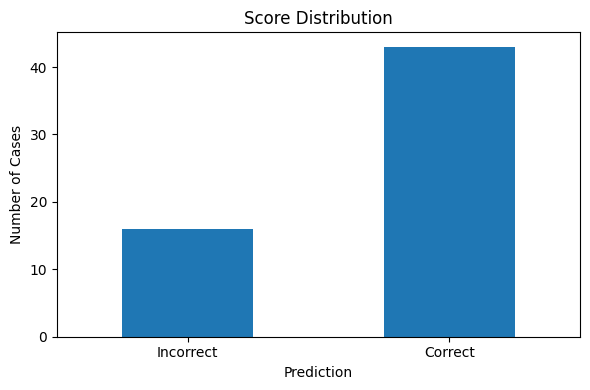

In [8]:
print(f'Overall Accuracy: {accuracy:.2%} ({correct}/{total})')

# Score Distribution
score_counts = df['score'].value_counts().sort_index()
plt.figure(figsize=(6,4))
score_counts.plot(kind='bar')
plt.xticks([0, 1], ['Incorrect', 'Correct'], rotation=0)
plt.title('Score Distribution')
plt.xlabel('Prediction')
plt.ylabel('Number of Cases')
plt.tight_layout()
plt.show()

/tmp/ipykernel_28605/1342351476.py:8: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


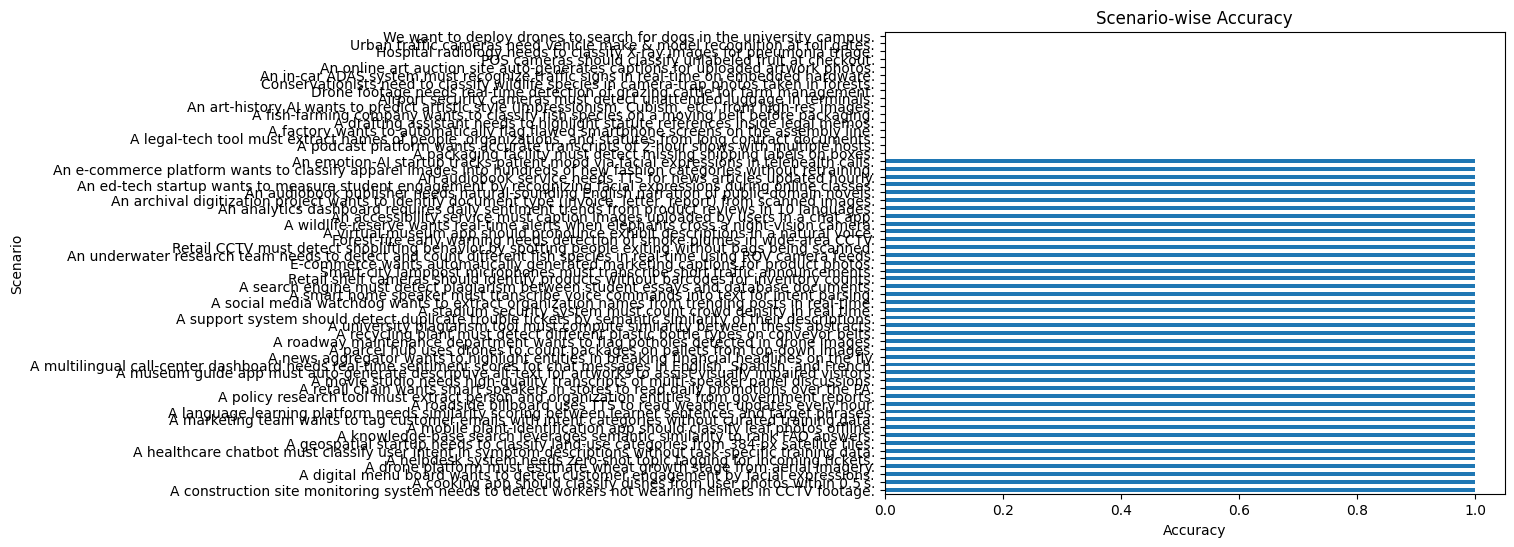

In [10]:
# Scenario-wise Performance (Top 10 scenarios by frequency)
scenario_perf = df.groupby('scenario')['score'].mean().sort_values(ascending=False)
plt.figure(figsize=(8,6))
scenario_perf.plot(kind='barh')
plt.title('Scenario-wise Accuracy')
plt.xlabel('Accuracy')
plt.ylabel('Scenario')
plt.tight_layout()
plt.show()

In [11]:
# Display sample errors (up to 5)
print("\nSample Errors:")
print(df[df['score'] == 0][['scenario', 'suggetion', 'ground_truth']].head())


Sample Errors:
                                             scenario  \
0   We want to deploy drones to search for dogs in...   
2   A factory wants to automatically flag flawed s...   
4   Conservationists need to classify wildlife spe...   
8   A legal‑tech tool must extract names of people...   
15  An in‑car ADAS system must recognize traffic s...   

                                            suggetion  \
0   ['Ultralytics YOLOv8n', 'Ultralytics YOLOv8s',...   
2                              ['Edge-Optimized CNN']   
4   ['Microsoft Swin-Large-Patch4-Window12-384-IN2...   
8                            Custom Legal-NER Service   
15                                Ultralytics YOLOv8n   

                                         ground_truth  
0                              ['Ultralytics/YOLOv8']  
2   ['microsoft/resnet-50', 'microsoft/swin-large-...  
4   ['microsoft/cvt-13', 'google/vit-base-patch16-...  
8                             ['dslim/bert-base-NER']  
15                

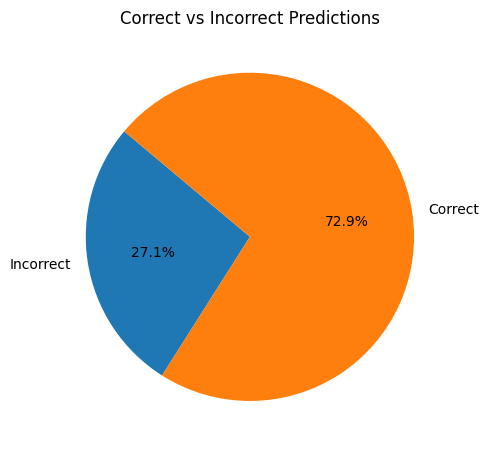

In [12]:
plt.figure(figsize=(5,5))
plt.pie(score_counts, labels=['Incorrect', 'Correct'], autopct='%1.1f%%', startangle=140)
plt.title('Correct vs Incorrect Predictions')
plt.tight_layout()
plt.show()